In [1]:
# Configuration and imports
import sys
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for _ in range(3):
    if (ROOT / 'src').is_dir():
        break
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SETTINGS = ROOT / 'settings'
REGISTRY = SETTINGS / 'data_registry_base.yaml'

# --- User inputs ---
FARM_PROFILES = SETTINGS / 'farm_profile_base.yaml'
ENERGY_CONFIG = SETTINGS / 'energy_system_base.yaml'
ENERGY_POLICY = SETTINGS / 'energy_policy_base.yaml'
COMMUNITY_CONFIG = SETTINGS / 'community_demands_base.yaml'
WATER_SYSTEMS = SETTINGS / 'water_systems_base.yaml'
WATER_POLICY = SETTINGS / 'water_policy_base.yaml'

# Objective: 'minimize_variance' (flatten demand) or 'match_supply' (align with energy supply)
OBJECTIVE = 'match_supply'

# Number of years to optimize over (None = all available data)
N_YEARS = 3

# Minimum sub-field area (ha) — smaller allocations are merged into larger sub-fields
MIN_AREA_HA = 0.1

# Minimum planted area as percent of initial total (1.0 = all area planted, 0.7 = allow 30% reduction)
MIN_PLANTED_PCT = 0.7

# Output path for the optimized profile (set to None to skip saving)
OUTPUT_PATH = SETTINGS / 'farm_profile_optimized.yaml'

In [2]:
# Run planting optimizer and print irrigation demand summary
from src.planting_optimizer import optimize_planting_schedule, save_optimized_profile

result = optimize_planting_schedule(
    farm_profiles_path=FARM_PROFILES,
    registry_path=REGISTRY,
    energy_config_path=ENERGY_CONFIG,
    community_config_path=COMMUNITY_CONFIG,
    objective=OBJECTIVE,
    min_area_ha=MIN_AREA_HA,
    min_planted_pct=MIN_PLANTED_PCT,
    n_years=N_YEARS,
    root_dir=ROOT,
)

s = result['summary']
n_years_label = f"first {N_YEARS} years" if N_YEARS else "all years"
print(f"Objective: {s['objective']} ({n_years_label})")
print(f"Schedules evaluated: {s['n_schedules_evaluated']}")
print(f"Fields: {s['n_fields_before']} → {s['n_fields_after']}")
print(f"Planted area: {s['area_ha_before']:.2f} → {s['area_ha_after']:.2f} ha ({s['planted_area_pct']:.1f}%)")
print(f"Irrigation variance reduction: {s['variance_reduction_pct']:.1f}%")
print(f"\nIrrigation Demand — Before → After:")
print(f"  Peak:  {s['before']['peak_m3']:.0f} → {s['after']['peak_m3']:.0f} m³/day")
print(f"  Mean:  {s['before']['mean_m3']:.1f} → {s['after']['mean_m3']:.1f} m³/day")
print(f"  CV:    {s['before']['cv']:.3f} → {s['after']['cv']:.3f}")

Objective: match_supply (first 3 years)
Schedules evaluated: 173
Fields: 4 → 45
Planted area: 10.00 → 10.00 ha (100.0%)
Irrigation variance reduction: 55.8%

Irrigation Demand — Before → After:
  Peak:  948 → 726 m³/day
  Mean:  270.2 → 284.8 m³/day
  CV:    0.844 → 0.533


In [3]:
# Save optimized profile, then run full water+energy pipeline for both profiles
if OUTPUT_PATH is not None:
    save_optimized_profile(result['farm_config'], OUTPUT_PATH)

from src.water_balance import compute_daily_water_balance
from src.energy_balance import compute_daily_energy_balance

def run_pipeline(farm_path):
    """Run water balance → energy balance for a given farm profile."""
    wb = compute_daily_water_balance(
        farm_profiles_path=farm_path,
        water_systems_path=WATER_SYSTEMS,
        water_policy_path=WATER_POLICY,
        community_config_path=COMMUNITY_CONFIG,
        registry_path=REGISTRY,
        root_dir=ROOT,
    )
    eb = compute_daily_energy_balance(
        energy_config_path=ENERGY_CONFIG,
        energy_policy_path=ENERGY_POLICY,
        community_config_path=COMMUNITY_CONFIG,
        farm_profiles_path=farm_path,
        registry_path=REGISTRY,
        water_balance_df=wb,
        root_dir=ROOT,
    )
    return wb, eb

wb_before, eb_before = run_pipeline(FARM_PROFILES)
wb_after, eb_after = run_pipeline(OUTPUT_PATH)
print(f"Baseline energy balance: {len(eb_before)} days")
print(f"Optimized energy balance: {len(eb_after)} days")

/Users/dpbirge/GITHUB/community-agri-pv/src/irrigation_demand.py:258: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result['total_demand_m3'] = result[demand_cols].sum(axis=1).round(3)
/Users/dpbirge/GITHUB/community-agri-pv/src/irrigation_demand.py:259: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result['crop_tds_requirement_ppm'] = _compute_tds_requirement(result, crop_cols, crop_tds)


/Users/dpbirge/GITHUB/community-agri-pv/src/water_balance.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result['over_delivery_m3'] = (
/Users/dpbirge/GITHUB/community-agri-pv/src/water_balance.py:173: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result['balance_check'] = (


Baseline energy balance: 5479 days
Optimized energy balance: 5479 days


In [4]:
# Energy balance comparison — key metrics
def energy_metrics(eb, wb, label):
    """Summarize energy balance outcomes."""
    total_demand = eb['total_demand_kwh'].sum()
    total_renewable = eb['total_renewable_kwh'].sum()
    water_energy = wb['total_water_energy_kwh'].sum()
    grid_import = eb['grid_import_kwh'].sum()
    grid_export = eb['grid_export_kwh'].sum()
    gen_kwh = eb['generator_kwh'].sum() if 'generator_kwh' in eb.columns else 0
    deficit_days = (eb['total_demand_kwh'] > eb['total_renewable_kwh']).sum()
    surplus = (eb['total_renewable_kwh'] - eb['total_demand_kwh']).clip(lower=0)
    deficit = (eb['total_demand_kwh'] - eb['total_renewable_kwh']).clip(lower=0)

    print(f"\n{'=' * 50}")
    print(f"  {label}")
    print(f"{'=' * 50}")
    print(f"  Total demand:        {total_demand:>10,.0f} kWh")
    print(f"    Community demand:  {eb['community_energy_demand_kwh'].sum():>10,.0f} kWh")
    print(f"    Water energy:      {water_energy:>10,.0f} kWh")
    print(f"      Pumping:         {wb['pumping_energy_kwh'].sum():>10,.0f} kWh")
    print(f"      Treatment:       {wb['treatment_energy_kwh'].sum():>10,.0f} kWh")
    print(f"      Application:     {wb['application_energy_kwh'].sum():>10,.0f} kWh")
    print(f"  Total renewable:     {total_renewable:>10,.0f} kWh")
    print(f"  Grid import:         {grid_import:>10,.0f} kWh")
    print(f"  Grid export:         {grid_export:>10,.0f} kWh")
    print(f"  Generator:           {gen_kwh:>10,.0f} kWh")
    print(f"  Deficit days:        {deficit_days:>10d} / {len(eb)}")
    print(f"  Peak daily deficit:  {deficit.max():>10,.0f} kWh")
    print(f"  Self-sufficiency:    {(1 - grid_import / total_demand) * 100:>9.1f}%")

energy_metrics(eb_before, wb_before, "BASELINE")
energy_metrics(eb_after, wb_after, "OPTIMIZED")


  BASELINE
  Total demand:         6,192,036 kWh
    Community demand:   4,049,017 kWh
    Water energy:       2,143,019 kWh
      Pumping:            465,348 kWh
      Treatment:        1,587,057 kWh
      Application:         90,614 kWh
  Total renewable:      6,030,176 kWh
  Grid import:            523,340 kWh
  Grid export:            735,661 kWh
  Generator:              378,970 kWh
  Deficit days:              2861 / 5479
  Peak daily deficit:       1,082 kWh
  Self-sufficiency:         91.5%

  OPTIMIZED
  Total demand:         6,354,303 kWh
    Community demand:   4,049,017 kWh
    Water energy:       2,305,286 kWh
      Pumping:            500,354 kWh
      Treatment:        1,712,080 kWh
      Application:         92,852 kWh
  Total renewable:      6,030,176 kWh
  Grid import:            589,325 kWh
  Grid export:            359,969 kWh
  Generator:              101,539 kWh
  Deficit days:              3399 / 5479
  Peak daily deficit:         862 kWh
  Self-sufficiency:    

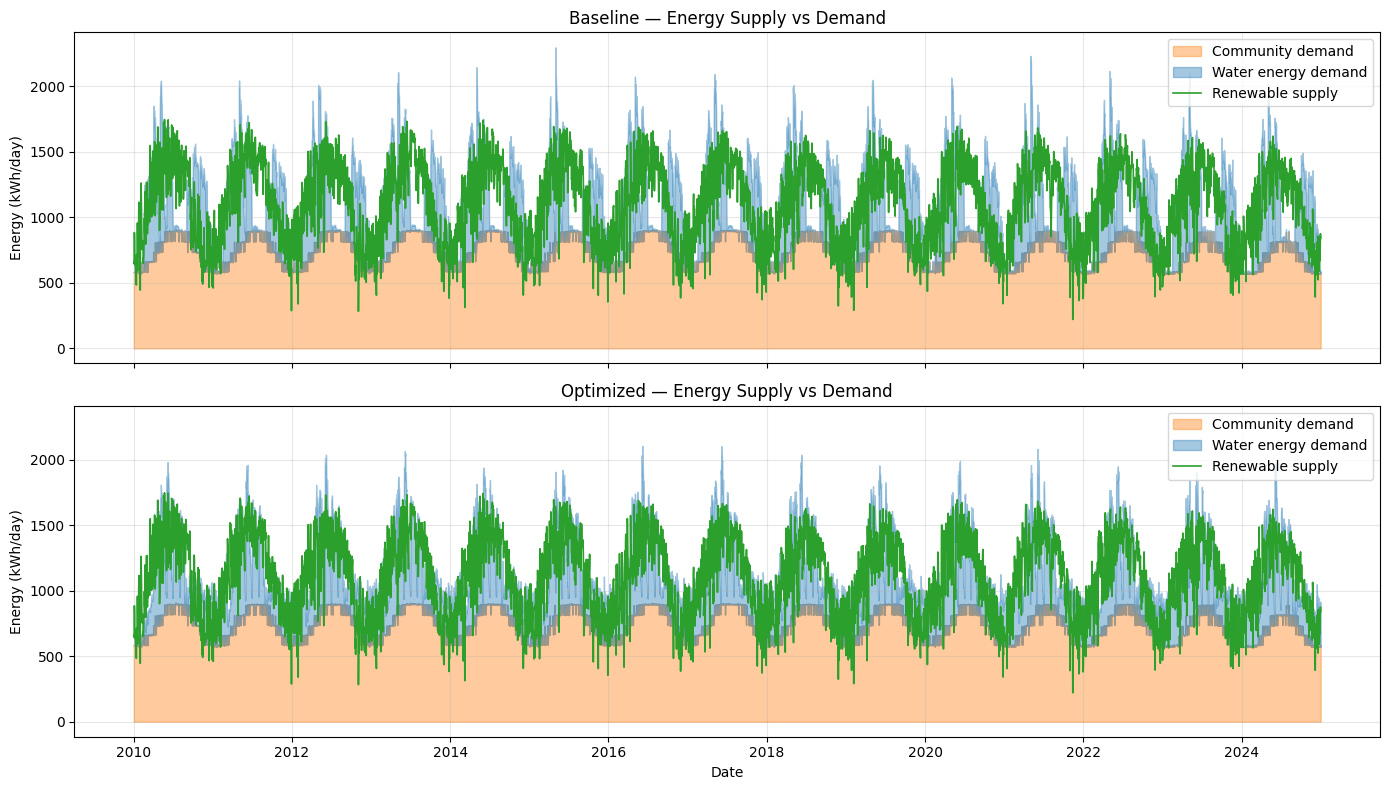

In [5]:
# Energy supply vs demand — before and after optimization
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

for ax, eb, wb, label in [(axes[0], eb_before, wb_before, 'Baseline'),
                           (axes[1], eb_after, wb_after, 'Optimized')]:
    days = eb['day']
    renewable = eb['total_renewable_kwh']
    community = eb['community_energy_demand_kwh']
    water_e = wb.set_index('day')['total_water_energy_kwh'].reindex(days).fillna(0).values

    ax.fill_between(days, 0, community, alpha=0.4, label='Community demand', color='#ff7f0e')
    ax.fill_between(days, community, community + water_e, alpha=0.4, label='Water energy demand', color='#1f77b4')
    ax.plot(days, renewable, color='#2ca02c', linewidth=1.2, label='Renewable supply')
    ax.set_ylabel('Energy (kWh/day)')
    ax.set_title(f'{label} — Energy Supply vs Demand')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

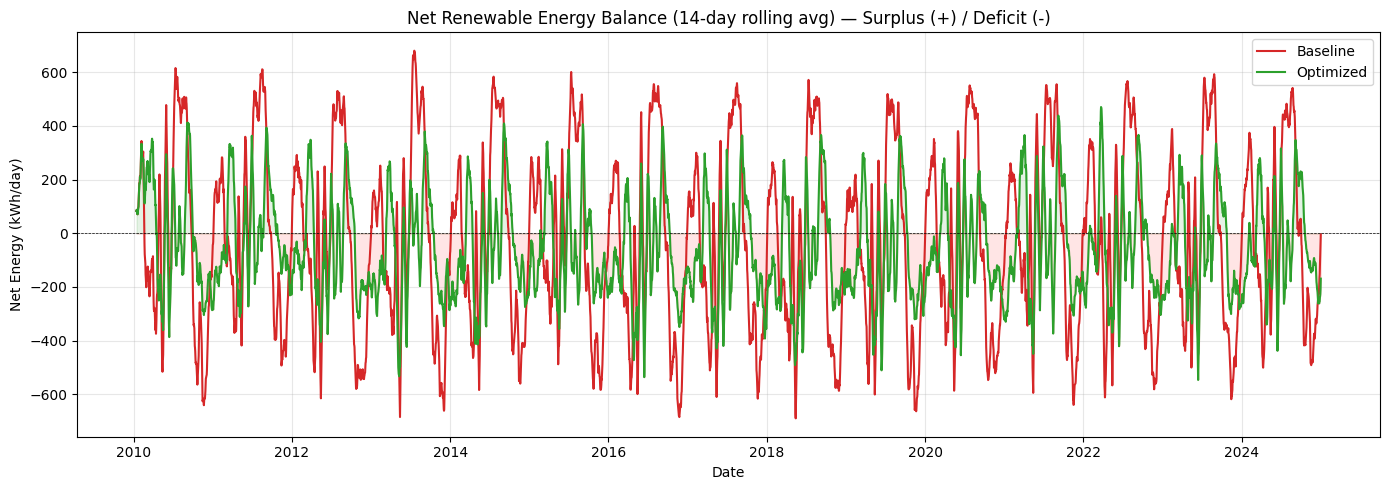

In [6]:
# Daily energy surplus/deficit comparison (14-day rolling average)
fig, ax = plt.subplots(figsize=(14, 5))

for eb, color, label in [(eb_before, '#d62728', 'Baseline'),
                          (eb_after, '#2ca02c', 'Optimized')]:
    net = eb.set_index('day')['total_renewable_kwh'] - eb.set_index('day')['total_demand_kwh']
    rolling = net.rolling(14).mean()
    ax.plot(rolling.index, rolling, color=color, linewidth=1.5, label=label)

ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.fill_between(rolling.index, 0, rolling.clip(lower=0).values, alpha=0.1, color='green')
ax.fill_between(rolling.index, rolling.clip(upper=0).values, 0, alpha=0.1, color='red')
ax.set_ylabel('Net Energy (kWh/day)')
ax.set_xlabel('Date')
ax.set_title('Net Renewable Energy Balance (14-day rolling avg) — Surplus (+) / Deficit (-)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Optimized planting schedule
print(yaml.dump(result['farm_config'], default_flow_style=False, sort_keys=False))

config_name: baseline_farm_collective_optimized
farms:
- name: farm_1
  fields:
  - name: north_field_s1
    area_ha: 0.14
    water_system: main_irrigation
    irrigation_system: drip
    condition: openfield
    plantings:
    - crop: kale
      plantings:
      - jan22
    - crop: tomato
      plantings:
      - jul22
  - name: north_field_s2
    area_ha: 0.1
    water_system: main_irrigation
    irrigation_system: drip
    condition: openfield
    plantings:
    - crop: kale
      plantings:
      - nov21
    - crop: tomato
      plantings:
      - apr01
  - name: north_field_s3
    area_ha: 0.14
    water_system: main_irrigation
    irrigation_system: drip
    condition: openfield
    plantings:
    - crop: kale
      plantings:
      - nov21
    - crop: tomato
      plantings:
      - apr11
  - name: north_field_s4
    area_ha: 0.12
    water_system: main_irrigation
    irrigation_system: drip
    condition: openfield
    plantings:
    - crop: kale
      plantings:
      - dec01